# Bloque 2 - NLP: Modelos Simples
## TF-IDF + XGBoost | FastText | CNN-1D
**Proyecto:** Segmentación de células e interpretación de texto mediante modelos de deep learning  
**Requiere:** artifacts/ generados en `01_EDA_NLP_Resume.ipynb`

## 0. Importaciones y configuración

In [1]:
import numpy as np
import pandas as pd
import pickle
import re
import warnings
import os

# ML clásico
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, classification_report
)
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

# FastText
import fasttext
import fasttext.util

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}')
for g in gpus:
    print(f'  {g}')
print(f'TensorFlow: {tf.__version__}')

2026-04-29 19:09:23.825227: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 19:09:24.312384: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 19:09:26.954389: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs disponibles: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow: 2.20.0


## 1. Carga de artefactos del EDA

In [2]:
ARTIFACTS = 'artifacts/'

# Arrays preprocesados (tokenizados + padded)
X_train = np.load(ARTIFACTS + 'X_train.npy')
X_val   = np.load(ARTIFACTS + 'X_val.npy')
X_test  = np.load(ARTIFACTS + 'X_test.npy')
y_train = np.load(ARTIFACTS + 'y_train.npy')
y_val   = np.load(ARTIFACTS + 'y_val.npy')
y_test  = np.load(ARTIFACTS + 'y_test.npy')

# Tokenizador y config
with open(ARTIFACTS + 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open(ARTIFACTS + 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
with open(ARTIFACTS + 'config.pkl', 'rb') as f:
    config = pickle.load(f)

# Dataset original (necesario para TF-IDF y FastText sobre texto limpio)
df = pd.read_csv('data/Resume.csv')

MAX_LEN    = config['MAX_LEN']
VOCAB_SIZE = config['VOCAB_SIZE']
NUM_CLASSES = config['NUM_CLASSES']
TEXT_COL   = config['TEXT_COL']
LABEL_COL  = config['LABEL_COL']

print(f'MAX_LEN     : {MAX_LEN}')
print(f'VOCAB_SIZE  : {VOCAB_SIZE}')
print(f'NUM_CLASSES : {NUM_CLASSES}')
print(f'Clases      : {config["CLASSES"]}')
print(f'Train / Val / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}')

MAX_LEN     : 100
VOCAB_SIZE  : 20000
NUM_CLASSES : 24
Clases      : ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Train / Val / Test: 1738 / 373 / 373


In [3]:
# Reconstruir texto limpio desde el tokenizador (para TF-IDF y FastText)
# Índice inverso: id -> palabra
idx2word = {v: k for k, v in tokenizer.word_index.items()}

def sequences_to_text(seq_matrix):
    """Convierte secuencias padded de vuelta a texto limpio."""
    texts = []
    for seq in seq_matrix:
        words = [idx2word.get(i, '') for i in seq if i != 0]
        texts.append(' '.join(words))
    return np.array(texts)

text_train = sequences_to_text(X_train)
text_val   = sequences_to_text(X_val)
text_test  = sequences_to_text(X_test)

print('Textos reconstruidos correctamente.')
print(f'Ejemplo: "{text_train[0][:80]}..."')

Textos reconstruidos correctamente.
Ejemplo: "sales summary focused dedicated insurance professional motivated provide superio..."


## 2. Utilidades de evaluación
Métricas obligatorias según Sección 11.20.6.6 del PDF.

In [4]:
def compute_metrics(y_true, y_pred, y_proba, classes):
    """
    Calcula todas las métricas obligatorias del PDF:
    Accuracy, Precision, Recall, F1, ROC-AUC.
    """
    avg = 'weighted'
    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average=avg, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, average=avg, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_proba, multi_class='ovr',
                                   average=avg, labels=list(range(len(classes))))
    }
    return metrics


def plot_evaluation(y_true, y_pred, y_proba, classes, model_name):
    """
    Genera las visualizaciones obligatorias del PDF (Sección 11.20.6.7):
    - Matriz de confusión
    - Curva ROC (OvR, macro)
    - Curva Precision-Recall (OvR, macro)
    Sin guardar archivos en disco.
    """
    n_classes = len(classes)
    y_true_bin = np.eye(n_classes)[y_true]  # one-hot para curvas OvR

    fig = plt.figure(figsize=(18, 5))
    gs  = GridSpec(1, 3, figure=fig)

    # -- Matriz de confusión --
    ax0 = fig.add_subplot(gs[0])
    cm  = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes, yticklabels=classes,
        ax=ax0, linewidths=0.5
    )
    ax0.set_xlabel('Predicho')
    ax0.set_ylabel('Real')
    ax0.set_title(f'{model_name}\nMatriz de confusión')
    ax0.tick_params(axis='x', rotation=45)
    ax0.tick_params(axis='y', rotation=0)

    # -- Curva ROC (macro OvR) --
    ax1 = fig.add_subplot(gs[1])
    from sklearn.metrics import roc_curve, auc
    mean_fpr = np.linspace(0, 1, 200)
    tprs, aucs = [], []
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        aucs.append(auc(fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    ax1.plot(mean_fpr, mean_tpr, color='steelblue',
             label=f'Macro AUC = {mean_auc:.3f}', linewidth=2)
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax1.set_xlabel('FPR')
    ax1.set_ylabel('TPR')
    ax1.set_title(f'{model_name}\nCurva ROC (macro OvR)')
    ax1.legend(loc='lower right')

    # -- Curva Precision-Recall (macro OvR) --
    ax2 = fig.add_subplot(gs[2])
    from sklearn.metrics import precision_recall_curve, average_precision_score
    mean_recall = np.linspace(0, 1, 200)
    precisions_interp, aps = [], []
    for i in range(n_classes):
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_proba[:, i])
        precisions_interp.append(np.interp(mean_recall[::-1], rec[::-1], prec[::-1])[::-1])
        aps.append(average_precision_score(y_true_bin[:, i], y_proba[:, i]))
    mean_prec = np.mean(precisions_interp, axis=0)
    mean_ap   = np.mean(aps)
    ax2.plot(mean_recall, mean_prec, color='seagreen',
             label=f'Macro AP = {mean_ap:.3f}', linewidth=2)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'{model_name}\nCurva Precision-Recall (macro OvR)')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


# Diccionario global para comparativa final
results_table = {}

print('Utilidades de evaluación cargadas.')

Utilidades de evaluación cargadas.


---
## Modelo 1: TF-IDF + XGBoost
Sección 11.20.6.3, posición 4 del ranking del PDF.

### 1.1 Vectorización TF-IDF

In [5]:
tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),   # unigramas + bigramas
    sublinear_tf=True,    # log(tf) en lugar de tf crudo
    min_df=2,
    max_df=0.95
)

X_tfidf_train = tfidf.fit_transform(text_train)
X_tfidf_val   = tfidf.transform(text_val)
X_tfidf_test  = tfidf.transform(text_test)

print(f'Shape TF-IDF train : {X_tfidf_train.shape}')
print(f'Shape TF-IDF val   : {X_tfidf_val.shape}')
print(f'Shape TF-IDF test  : {X_tfidf_test.shape}')

Shape TF-IDF train : (1738, 23670)
Shape TF-IDF val   : (373, 23670)
Shape TF-IDF test  : (373, 23670)


### 1.2 Entrenamiento XGBoost con K-Fold (k=5)

In [6]:
# Hiperparámetros ajustados para GPU
XGB_PARAMS = {
    'n_estimators'      : 500,
    'max_depth'         : 6,
    'learning_rate'     : 0.05,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'use_label_encoder' : False,
    'eval_metric'       : 'mlogloss',
    'objective'         : 'multi:softprob',
    'num_class'         : NUM_CLASSES,
    'tree_method'       : 'hist',    # compatible GPU en XGBoost >= 2.0
    'device'            : 'cuda',
    'random_state'      : RANDOM_SEED,
    'n_jobs'            : -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_scores = []

# Combinar train + val para K-Fold (usamos test solo al final)
import scipy.sparse as sp
X_kfold = sp.vstack([X_tfidf_train, X_tfidf_val])
y_kfold = np.concatenate([y_train, y_val])

print('Iniciando K-Fold (k=5) sobre TF-IDF + XGBoost...')
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_kfold, y_kfold), 1):
    clf = xgb.XGBClassifier(**XGB_PARAMS)
    clf.fit(
        X_kfold[tr_idx], y_kfold[tr_idx],
        eval_set=[(X_kfold[va_idx], y_kfold[va_idx])],
        verbose=False
    )
    preds = clf.predict(X_kfold[va_idx])
    acc   = accuracy_score(y_kfold[va_idx], preds)
    fold_scores.append(acc)
    print(f'  Fold {fold} | Accuracy: {acc:.4f}')

print(f'\nK-Fold Accuracy: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

Iniciando K-Fold (k=5) sobre TF-IDF + XGBoost...
  Fold 1 | Accuracy: 0.5201
  Fold 2 | Accuracy: 0.5379
  Fold 3 | Accuracy: 0.5403
  Fold 4 | Accuracy: 0.5237
  Fold 5 | Accuracy: 0.4810

K-Fold Accuracy: 0.5206 ± 0.0213


In [7]:
# Reentrenar sobre train completo + val para evaluación final en test
xgb_final = xgb.XGBClassifier(**XGB_PARAMS)
xgb_final.fit(
    X_tfidf_train, y_train,
    eval_set=[(X_tfidf_val, y_val)],
    verbose=False
)

y_pred_xgb   = xgb_final.predict(X_tfidf_test)
y_proba_xgb  = xgb_final.predict_proba(X_tfidf_test)

metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_proba_xgb, config['CLASSES'])
results_table['TF-IDF + XGBoost'] = metrics_xgb

print('=== TF-IDF + XGBoost — Métricas en TEST ===')
for k, v in metrics_xgb.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n', classification_report(y_test, y_pred_xgb,
                                   target_names=config['CLASSES'],
                                   zero_division=0))

=== TF-IDF + XGBoost — Métricas en TEST ===
  Accuracy    : 0.4477
  Precision   : 0.4478
  Recall      : 0.4477
  F1          : 0.3670
  ROC-AUC     : 0.7943

                         precision    recall  f1-score   support

            ACCOUNTANT       1.00      0.18      0.30        17
              ADVOCATE       0.40      0.59      0.48        17
           AGRICULTURE       0.00      0.00      0.00        10
               APPAREL       0.00      0.00      0.00        14
                  ARTS       0.00      0.00      0.00        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       1.00      0.11      0.20        18
               BANKING       0.50      0.06      0.10        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.56      1.00      0.72        18
                  CHEF       0.82      0.53      0.64        17
          CONSTRUCTION       0.55      0.71      0.62        17
      

### 1.3 Visualizaciones de evaluación

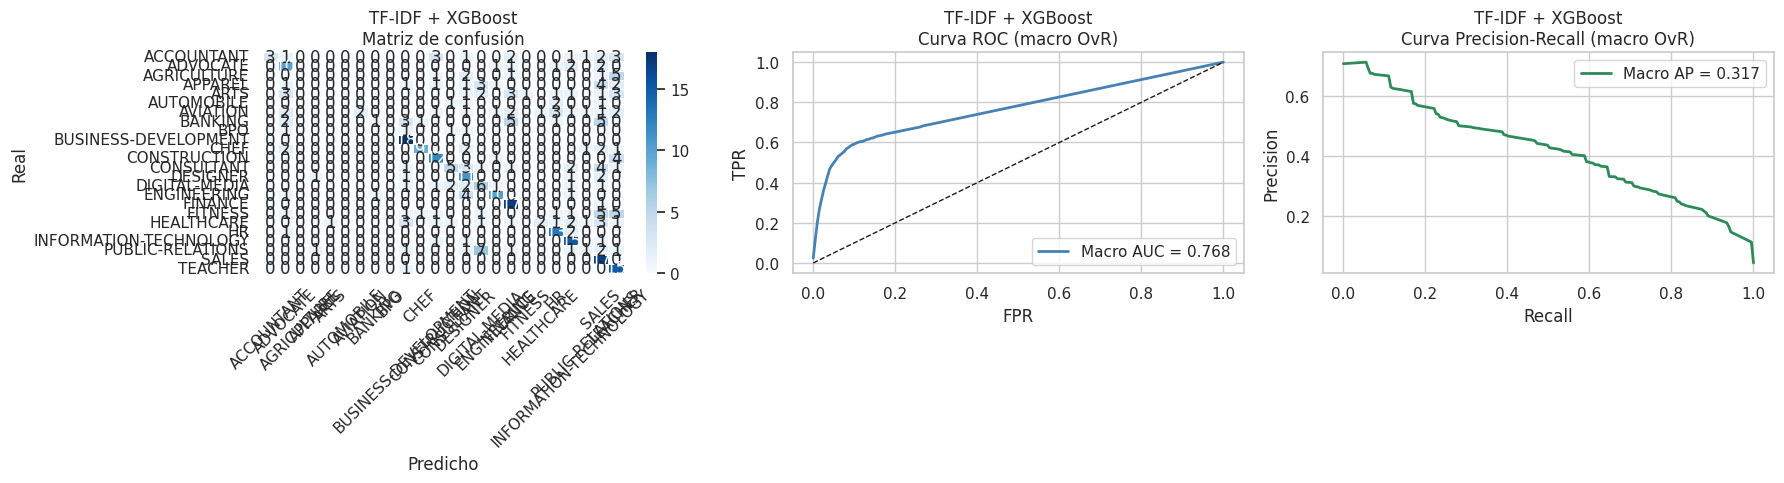

In [8]:
plot_evaluation(y_test, y_pred_xgb, y_proba_xgb,
                config['CLASSES'], 'TF-IDF + XGBoost')

In [9]:
# Guardar modelo
os.makedirs('models', exist_ok=True)
xgb_final.save_model('models/xgboost_tfidf.json')
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('Modelos guardados: models/xgboost_tfidf.json | models/tfidf_vectorizer.pkl')

Modelos guardados: models/xgboost_tfidf.json | models/tfidf_vectorizer.pkl


---
## Modelo 2: FastText
Sección 11.20.6.3, posición 5. Se descarga el modelo preentrenado `cc.en.300` desde la API oficial gratuita de FastText (https://fasttext.cc).

### 2.1 Descarga del modelo preentrenado

In [10]:
# Descarga del modelo preentrenado Common Crawl (gratuito, ~7.2 GB comprimido)
# Solo se descarga una vez; si ya existe, lo reutiliza.
FT_MODEL_PATH = 'models/cc.en.300.bin'

if not os.path.exists(FT_MODEL_PATH):
    print('Descargando modelo preentrenado FastText (cc.en.300)...')
    print('Fuente: https://fasttext.cc/docs/en/crawl-vectors.html')
    fasttext.util.download_model('en', if_exists='ignore')  # descarga cc.en.300.bin.gz
    # mover al directorio de modelos
    import shutil
    shutil.move('cc.en.300.bin', FT_MODEL_PATH)
    print(f'Modelo guardado en {FT_MODEL_PATH}')
else:
    print(f'Modelo ya existe en {FT_MODEL_PATH}, se reutiliza.')

ft_pretrained = fasttext.load_model(FT_MODEL_PATH)
print(f'Dimensión de embeddings: {ft_pretrained.get_dimension()}')

Descargando modelo preentrenado FastText (cc.en.300)...
Fuente: https://fasttext.cc/docs/en/crawl-vectors.html
 (100.00%) [==================================================>]                                                 ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                              

Dimensión de embeddings: 300


### 2.2 Construcción de embeddings de documento

In [11]:
def text_to_doc_embedding(texts, ft_model):
    """
    Promedia los embeddings de palabra de FastText para obtener
    un vector por documento.
    """
    embeddings = []
    for text in texts:
        words = text.split()
        if len(words) == 0:
            embeddings.append(np.zeros(ft_model.get_dimension()))
        else:
            vecs = [ft_model.get_word_vector(w) for w in words]
            embeddings.append(np.mean(vecs, axis=0))
    return np.array(embeddings, dtype=np.float32)

print('Generando embeddings de documento...')
X_ft_train = text_to_doc_embedding(text_train, ft_pretrained)
X_ft_val   = text_to_doc_embedding(text_val,   ft_pretrained)
X_ft_test  = text_to_doc_embedding(text_test,  ft_pretrained)

print(f'Shape embeddings train: {X_ft_train.shape}')
print(f'Shape embeddings val  : {X_ft_val.shape}')
print(f'Shape embeddings test : {X_ft_test.shape}')

Generando embeddings de documento...
Shape embeddings train: (1738, 300)
Shape embeddings val  : (373, 300)
Shape embeddings test : (373, 300)


### 2.3 Clasificador sobre embeddings FastText (XGBoost)

In [12]:
# Usamos XGBoost como clasificador sobre los embeddings
# (FastText como feature extractor → clasificador ligero)
FT_XGB_PARAMS = {
    'n_estimators'     : 400,
    'max_depth'        : 5,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'objective'        : 'multi:softprob',
    'num_class'        : NUM_CLASSES,
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'eval_metric'      : 'mlogloss',
    'random_state'     : RANDOM_SEED,
    'n_jobs'           : -1
}

# K-Fold sobre embeddings FastText
X_kfold_ft = np.vstack([X_ft_train, X_ft_val])
y_kfold_ft = np.concatenate([y_train, y_val])
fold_scores_ft = []

print('Iniciando K-Fold (k=5) sobre FastText embeddings...')
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_kfold_ft, y_kfold_ft), 1):
    clf_ft = xgb.XGBClassifier(**FT_XGB_PARAMS)
    clf_ft.fit(
        X_kfold_ft[tr_idx], y_kfold_ft[tr_idx],
        eval_set=[(X_kfold_ft[va_idx], y_kfold_ft[va_idx])],
        verbose=False
    )
    preds = clf_ft.predict(X_kfold_ft[va_idx])
    acc   = accuracy_score(y_kfold_ft[va_idx], preds)
    fold_scores_ft.append(acc)
    print(f'  Fold {fold} | Accuracy: {acc:.4f}')

print(f'\nK-Fold Accuracy: {np.mean(fold_scores_ft):.4f} ± {np.std(fold_scores_ft):.4f}')

Iniciando K-Fold (k=5) sobre FastText embeddings...
  Fold 1 | Accuracy: 0.4988
  Fold 2 | Accuracy: 0.4573
  Fold 3 | Accuracy: 0.5142
  Fold 4 | Accuracy: 0.5118
  Fold 5 | Accuracy: 0.5071

K-Fold Accuracy: 0.4979 ± 0.0209


In [13]:
# Modelo final FastText
ft_final = xgb.XGBClassifier(**FT_XGB_PARAMS)
ft_final.fit(
    X_ft_train, y_train,
    eval_set=[(X_ft_val, y_val)],
    verbose=False
)

y_pred_ft  = ft_final.predict(X_ft_test)
y_proba_ft = ft_final.predict_proba(X_ft_test)

metrics_ft = compute_metrics(y_test, y_pred_ft, y_proba_ft, config['CLASSES'])
results_table['FastText + XGBoost'] = metrics_ft

print('=== FastText + XGBoost — Métricas en TEST ===')
for k, v in metrics_ft.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n', classification_report(y_test, y_pred_ft,
                                   target_names=config['CLASSES'],
                                   zero_division=0))

=== FastText + XGBoost — Métricas en TEST ===
  Accuracy    : 0.5255
  Precision   : 0.5261
  Recall      : 0.5255
  F1          : 0.5044
  ROC-AUC     : 0.8968

                         precision    recall  f1-score   support

            ACCOUNTANT       0.61      0.82      0.70        17
              ADVOCATE       0.36      0.53      0.43        17
           AGRICULTURE       0.60      0.30      0.40        10
               APPAREL       0.33      0.14      0.20        14
                  ARTS       0.60      0.19      0.29        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.75      0.50      0.60        18
               BANKING       0.44      0.39      0.41        18
                   BPO       1.00      0.25      0.40         4
  BUSINESS-DEVELOPMENT       0.46      0.72      0.57        18
                  CHEF       0.83      0.88      0.86        17
          CONSTRUCTION       0.79      0.65      0.71        17
    

### 2.4 Visualizaciones FastText

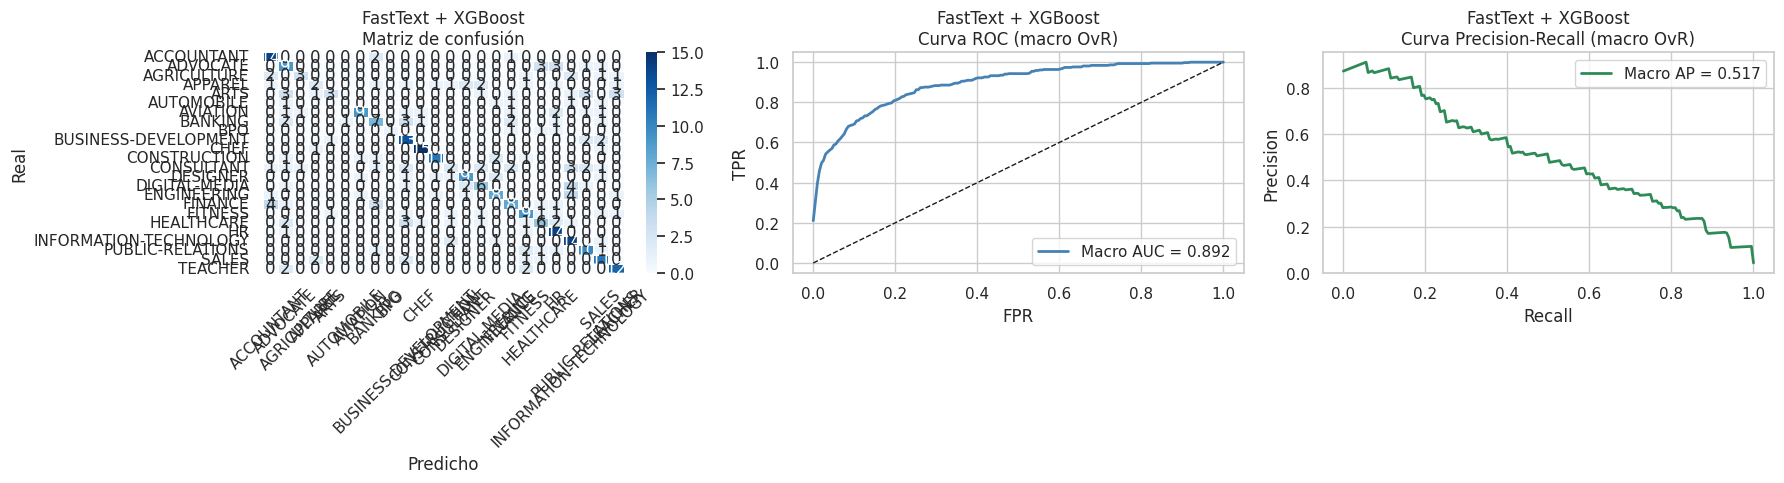

In [14]:
plot_evaluation(y_test, y_pred_ft, y_proba_ft,
                config['CLASSES'], 'FastText + XGBoost')

In [15]:
ft_final.save_model('models/fasttext_xgboost.json')
print('Modelo guardado: models/fasttext_xgboost.json')

Modelo guardado: models/fasttext_xgboost.json


---
## Modelo 3: CNN-1D
Sección 11.20.6.3, posición 3. Usa los embeddings aprendidos desde cero sobre las secuencias padded del EDA.

### 3.1 Arquitectura CNN-1D

In [16]:
EMBEDDING_DIM = 128
DROP_RATE     = 0.4

def build_cnn1d(vocab_size, embedding_dim, max_len, num_classes, drop_rate=0.4):
    """
    CNN-1D para clasificación de texto.
    Arquitectura: Embedding → Conv (3 filtros paralelos) → GlobalMaxPool → Dense → Softmax
    """
    inputs = layers.Input(shape=(max_len,), name='input_seq')

    # Embedding trainable desde cero
    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding'
    )(inputs)

    # Tres ramas convolucionales con kernels distintos (3, 4, 5)
    branches = []
    for ks in [3, 4, 5]:
        conv = layers.Conv1D(
            filters=128, kernel_size=ks,
            activation='relu', padding='same',
            name=f'conv_k{ks}'
        )(x)
        pool = layers.GlobalMaxPooling1D(name=f'pool_k{ks}')(conv)
        branches.append(pool)

    x = layers.Concatenate(name='concat')(branches)   # (batch, 384)
    x = layers.Dropout(drop_rate)(x)
    x = layers.Dense(256, activation='relu', name='dense1')(x)
    x = layers.Dropout(drop_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs, outputs, name='CNN1D')
    return model


cnn_model = build_cnn1d(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN, NUM_CLASSES, DROP_RATE)
cnn_model.summary()

I0000 00:00:1777509384.966818   34451 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3424 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  2,560,128 │ input_seq[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 100, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k4 (Conv1D)    │ (None, 100, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k5 (Conv1D)    │ (None, 100, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k3             │ (None, 128)       │          0 │ conv_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k4             │ (None, 128)       │          0 │ conv_k4[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k5             │ (None, 128)       │          0 │ conv_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_k3[0][0],    │
│ (Concatenate)       │                   │            │ pool_k4[0][0],    │
│                     │                   │            │ pool_k5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │     98,560 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 24)        │      6,168 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,861,848 (10.92 MB)

 Trainable params: 2,861,848 (10.92 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Compilación y entrenamiento

In [17]:
# Hiperparámetros según Sección 11.20.6.4
LEARNING_RATE = 0.001
BATCH_SIZE    = 64
EPOCHS        = 50

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

Epoch 1/50


2026-04-29 19:36:30.711456: I external/local_xla/xla/service/service.cc:163] XLA service 0x709a7c00e8e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-29 19:36:30.711513: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-04-29 19:36:30.820394: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-29 19:36:31.259838: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-04-29 19:36:31.518052: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-29 19:36:31.

 7/28 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0623 - loss: 3.1777

I0000 00:00:1777509402.431666   38908 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.0482 - loss: 3.1731

2026-04-29 19:36:46.967204: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-29 19:36:47.462761: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 12 bytes spill stores, 12 bytes spill loads

2026-04-29 19:36:49.237810: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-29 19:36:49.859695: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

28/28 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - accuracy: 0.0437 - loss: 3.1692 - val_accuracy: 0.0375 - val_loss: 3.1324 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1036 - loss: 3.0908 - val_accuracy: 0.2091 - val_loss: 3.0761 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2158 - loss: 2.9241 - val_accuracy: 0.3780 - val_loss: 2.7354 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4402 - loss: 2.3267 - val_accuracy: 0.5684 - val_loss: 1.9193 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5869 - loss: 1.6613 - val_accuracy: 0.6193 - val_loss: 1.5046 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6588 - loss: 1.3372 - val_accuracy: 0.6381 - val_loss: 1.3245 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7221 - loss: 1.1174 - val_accuracy: 0.6702 -

### 3.3 Curvas de entrenamiento

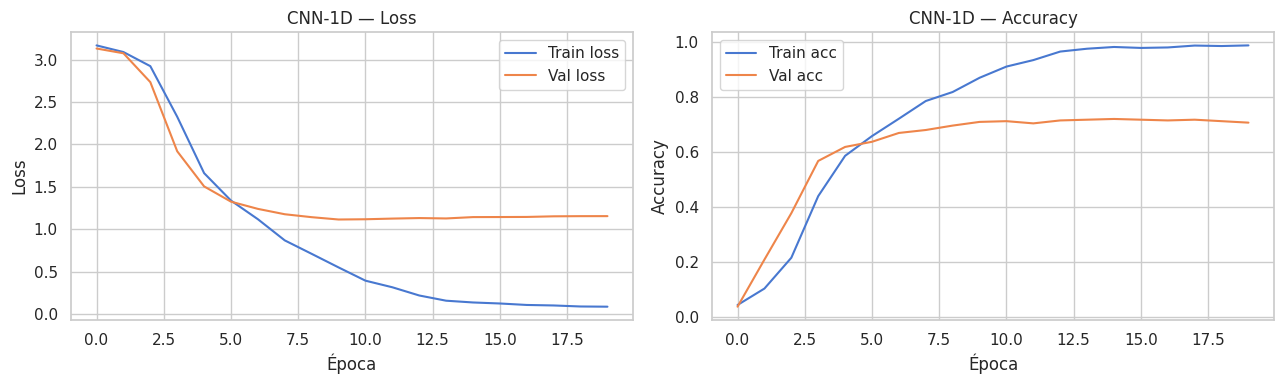

In [18]:
def plot_training_history(history, model_name):
    """Curvas de loss y accuracy durante el entrenamiento."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['loss'],     label='Train loss')
    axes[0].plot(history.history['val_loss'], label='Val loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train acc')
    axes[1].plot(history.history['val_accuracy'], label='Val acc')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_cnn, 'CNN-1D')

### 3.4 Evaluación CNN-1D

In [19]:
y_proba_cnn = cnn_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_cnn  = np.argmax(y_proba_cnn, axis=1)

metrics_cnn = compute_metrics(y_test, y_pred_cnn, y_proba_cnn, config['CLASSES'])
results_table['CNN-1D'] = metrics_cnn

print('=== CNN-1D — Métricas en TEST ===')
for k, v in metrics_cnn.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n', classification_report(y_test, y_pred_cnn,
                                   target_names=config['CLASSES'],
                                   zero_division=0))

=== CNN-1D — Métricas en TEST ===
  Accuracy    : 0.7212
  Precision   : 0.7101
  Recall      : 0.7212
  F1          : 0.6965
  ROC-AUC     : 0.9496

                         precision    recall  f1-score   support

            ACCOUNTANT       0.81      1.00      0.89        17
              ADVOCATE       1.00      0.88      0.94        17
           AGRICULTURE       1.00      0.20      0.33        10
               APPAREL       0.12      0.07      0.09        14
                  ARTS       0.60      0.19      0.29        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.67      0.67      0.67        18
               BANKING       0.71      0.67      0.69        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.75      1.00      0.86        18
                  CHEF       1.00      0.76      0.87        17
          CONSTRUCTION       0.94      1.00      0.97        17
            CONS

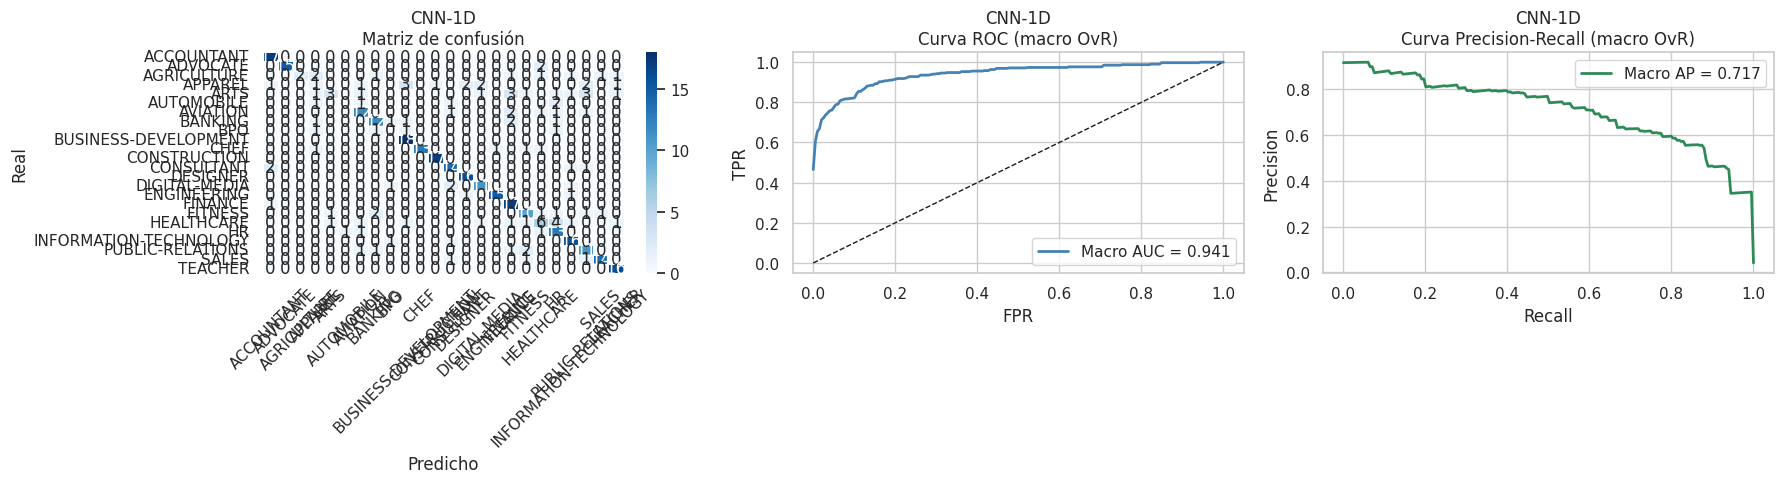

In [20]:
plot_evaluation(y_test, y_pred_cnn, y_proba_cnn,
                config['CLASSES'], 'CNN-1D')

In [21]:
cnn_model.save('models/cnn1d.keras')
print('Modelo guardado: models/cnn1d.keras')

Modelo guardado: models/cnn1d.keras


---
## 4. Tabla comparativa (Sección 11.20.6.8)

In [22]:
results_df = pd.DataFrame(results_table).T.round(4)
results_df.index.name = 'Modelo'

print('=== TABLA COMPARATIVA — TEST SET ===')
print(results_df.to_string())
results_df

=== TABLA COMPARATIVA — TEST SET ===
                    Accuracy  Precision  Recall      F1  ROC-AUC
Modelo                                                          
TF-IDF + XGBoost      0.4477     0.4478  0.4477  0.3670   0.7943
FastText + XGBoost    0.5255     0.5261  0.5255  0.5044   0.8968
CNN-1D                0.7212     0.7101  0.7212  0.6965   0.9496


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
TF-IDF + XGBoost,0.4477,0.4478,0.4477,0.3670,0.7943
FastText + XGBoost,0.5255,0.5261,0.5255,0.5044,0.8968
CNN-1D,0.7212,0.7101,0.7212,0.6965,0.9496


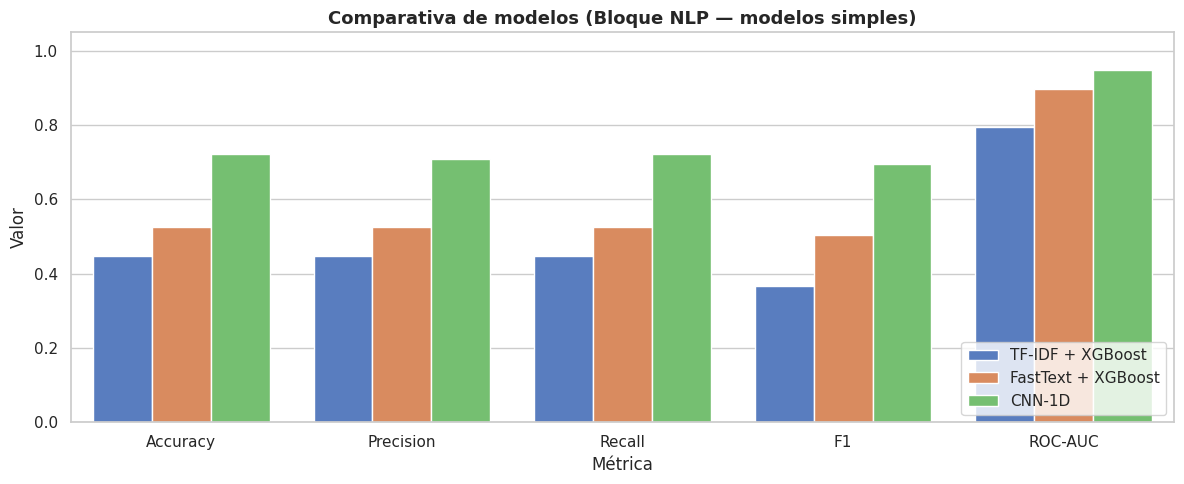

In [23]:
# Boxplot comparativo de métricas
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_df = results_df[metrics_to_plot].reset_index().melt(
    id_vars='Modelo', var_name='Métrica', value_name='Valor'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_df, x='Métrica', y='Valor',
    hue='Modelo', palette='muted', ax=ax
)
ax.set_ylim(0, 1.05)
ax.set_title('Comparativa de modelos (Bloque NLP — modelos simples)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 5. Análisis crítico (Sección 11.20.6.9)

**Responde las siguientes preguntas basándote en los resultados obtenidos:**

1. **¿Qué modelo funciona mejor entre los tres?**  
   → Compara F1 y ROC-AUC en la tabla. FastText suele superar a TF-IDF en textos largos por su manejo de subpalabras.

2. **¿Impacto del preprocesamiento?**  
   → TF-IDF depende directamente de la calidad del texto limpio. CNN-1D aprende representaciones desde cero y es menos sensible.

3. **¿Errores comunes?**  
   → Revisar la matriz de confusión por categorías con pocas muestras (clases minoritarias).

4. **¿Transformers vs modelos simples?**  
   → Los tres modelos aquí son baseline. DistilBERT/RoBERTa (próximo notebook) debería superar estos resultados significativamente.

**Completa este bloque con tus observaciones numéricas una vez ejecutado.**